# **Assignment 9**

**Name : Shantanu Kaute | Prn.no : 1252090007 | roll.no : 07**

**This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.**

**Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.**

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Data Preprocessing**

In [ ]:
df.dropna()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.drop_duplicates()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df['Genre']=df['Genre'].map({'Male':1,'Female':0})
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Elbow Method:**

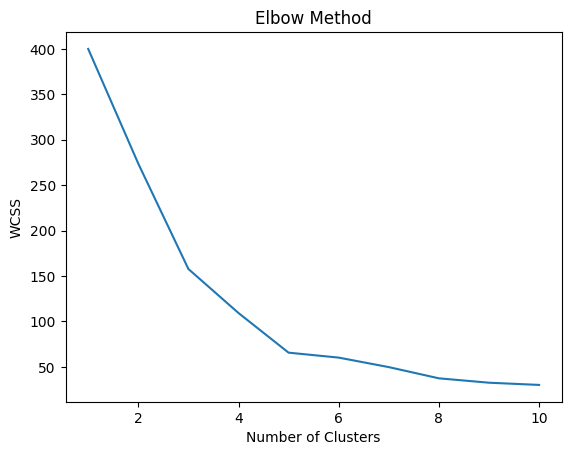

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# **K-Means:**

In [ ]:
kmeans_random = KMeans(n_clusters=5, init='random', random_state=42)
y_random = kmeans_random.fit_predict(X_scaled)

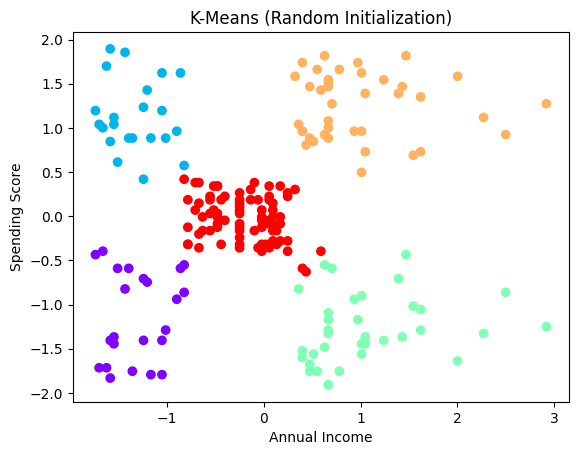

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_random, cmap='rainbow')
plt.title("K-Means (Random Initialization)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# **K-Means++**

In [ ]:
kmeans_plus = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_plus = kmeans_plus.fit_predict(X_scaled)

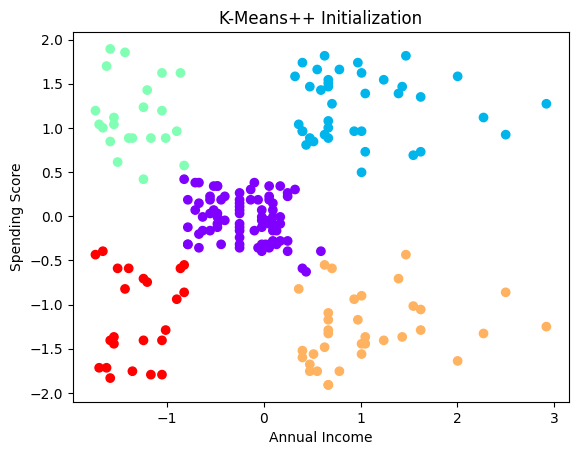

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_plus, cmap='rainbow')
plt.title("K-Means++ Initialization")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# **Silhouette Score**

In [ ]:
from sklearn.metrics import silhouette_score

score_random = silhouette_score(X_scaled, y_random)
score_plus = silhouette_score(X_scaled, y_plus)

print("K-Means Score:", score_random)
print("K-Means++ Score:", score_plus)

K-Means Score: 0.5546571631111091
K-Means++ Score: 0.5546571631111091


# **Train-Test Split (for KNN)**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_plus, test_size=0.2, random_state=42)

# **K-Nearest Neighbors (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# **Model Evaluation (KNN)**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.95
Confusion Matrix:
 [[18  0  0  0  0]
 [ 0  5  0  0  0]
 [ 1  0  2  0  0]
 [ 1  0  0 10  0]
 [ 0  0  0  0  3]]
